# TUGAS 2 - Analisis Audio & Noise Statis

---

**Nama:** Varasina Farmadani  
**NIM:** 123140107  
**Link Direktori GitHub:** https://github.com/sinavarasina/stm-if25-40305-123140107/tree/main/02_audio_noise_statis
---

**ACT OF TRANSPARENCY**  
Kode ini co-authored by gemini, saya sebagai author memahami 100% kode yang digunakan disini (anti copypasta). hal ini saya lakukan karena saya mengerjakan sudah dekat deadline.

---

# 1. Setup, Load Audio, dan Cek Metadata

In [ ]:
# bagian Import
import numpy as np
import librosa
# modul display librosa yang optimal untuk spektogram
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf

In [ ]:
# nama file audio
AUDIO_FILE = 'audio_original.wav'

# load file audio dengan sample rate yang 1:1
y, sr = librosa.load(AUDIO_FILE, sr=None)

# menghitung durasi dari total panjang sample di bagi sample rate
duration_sec = len(y) / sr

# mencari nilai amplitude tertinggi dan terendah dalam array sinyal
max_amplitude = np.max(y)
min_amplitude = np.min(y)

print(f"Sample Rate (fs): {sr} Hz")
print(f"Audio Duration: {duration_sec:.2f} seconds")
print(f"Total Samples: {len(y)} points")
print(f"Array Data Type: {y.dtype}")
print(f"Max Amplitude: {max_amplitude:.5f}")
print(f"Min Amplitude: {min_amplitude:.5f}")

Sample Rate (fs): 48000 Hz
Audio Duration: 12.41 seconds
Total Samples: 595596 points
Array Data Type: float32
Max Amplitude: 0.22369
Min Amplitude: -0.20789


# 2. 4D Visualization

## 2.1 Waveform (Amplitude - Time)

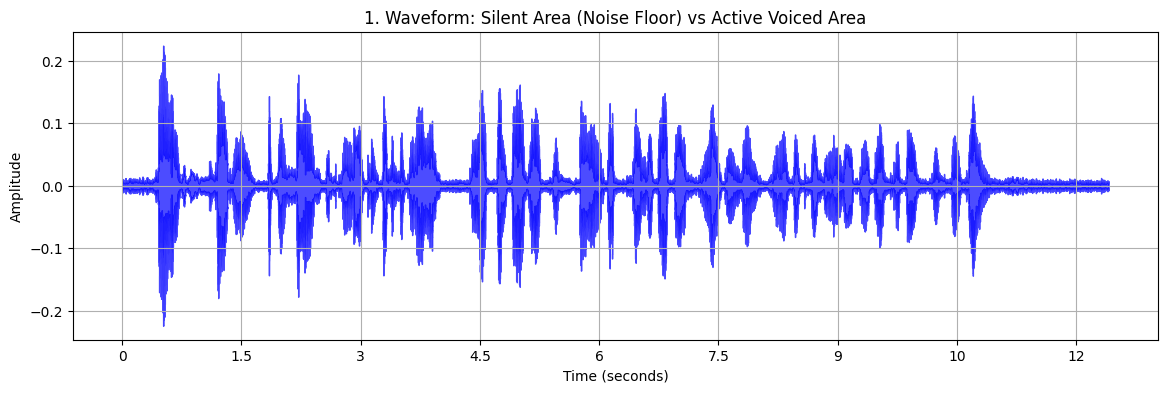

In [ ]:
# inisialisasi canvas lebar 14 tinggi 4
plt.figure(figsize=(14, 4))

# Menggambar fluktuasi Amplitude sinyal audio terhadap waktu
librosa.display.waveshow(y, sr=sr, color='blue', alpha=0.7)

# Memberikan judul deskriptif pada bagian atas plot Waveform
plt.title('1. Waveform: Silent Area (Noise Floor) vs Active Voiced Area')

plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.grid(True)

plt.show()

Di detik 0-0,4 dan 10,5 – 12,4 amplitudo hanya sekitar ±0,01 dan tidak nol. Itu noise floor dari kipas angin yang saya nyalakan disekitar mic . Saat membaca berita amplitudo naik sampai ±0,22 dengan pola amplitudo membesar ketika terucap kata dari pembicara. Karena amplitudo noise di gap antar kata tidak berubah, noise ini bisa di bilang bersifat statis.

## 2.2 FFT Spectrum (Aplitude - Frequency)

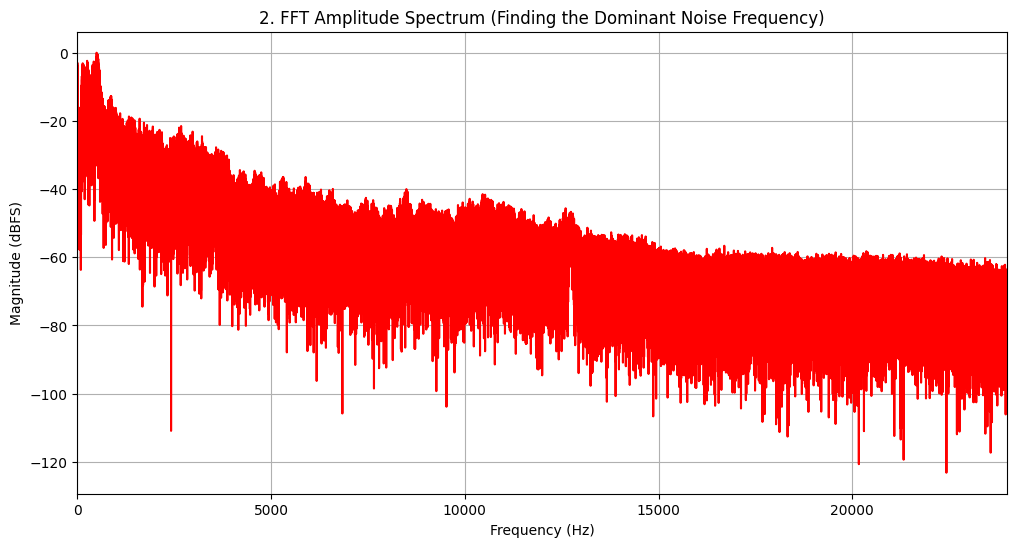

In [ ]:
# transformasi dari Time Domain ke Frequency Domain (Fast Fourier Transform) via NumPy
yf = np.fft.fft(y)
# Membangun array sumbu frekuensi dan mengambil hanya setengah bagian pertama (frekuensi positif)
xf = np.fft.fftfreq(len(y), 1 / sr)[:len(y)//2]
# Mengekstrak nilai absolut (Magnitude murni) dari array bilangan kompleks hasil FFT
magnitude_positive = np.abs(yf[:len(y)//2])
# Mengonversi array Magnitude linier menjadi skala logaritmik decibel (dBFS) dengan batas matematis
magnitude_dbfs = 20 * np.log10(magnitude_positive / np.max(magnitude_positive) + 1e-10)

# Membuka figur kanvas baru untuk plot spektrum berukuran 12x6 inci
plt.figure(figsize=(12, 6))
# Menggambar garis spektrum warna merah yang memetakan frekuensi terhadap desibel
plt.plot(xf, magnitude_dbfs, color='red')
# Menambahkan judul spesifik terkait FFT Amplitude Spectrum
plt.title('2. FFT Amplitude Spectrum (Finding the Dominant Noise Frequency)')
# Memberi label pada sumbu horizontal dengan satuan Hertz
plt.xlabel('Frequency (Hz)')
# Memberi label pada sumbu vertikal dengan satuan dBFS
plt.ylabel('Magnitude (dBFS)')
# Membatasi tampilan plot maksimum pada batas Nyquist (sr/2) agar relevan
plt.xlim(0, sr/2)
# Mengaktifkan garis grid
plt.grid(True)
# Menampilkan plot FFT ke layar
plt.show()

Energi paling besar ada di bawah ±1 kHz, lalu turun melandai sekitar −60 s.d. −80 dB di atas 12 kHz. Puncak sepertinya berada di ±500 Hz mungkin berasal dari suara + noise. Kalau untuk noise nya mungkin berada di sekitar ±400-500Hz

## 2.3 STFT Spectogram (Time - Freq)

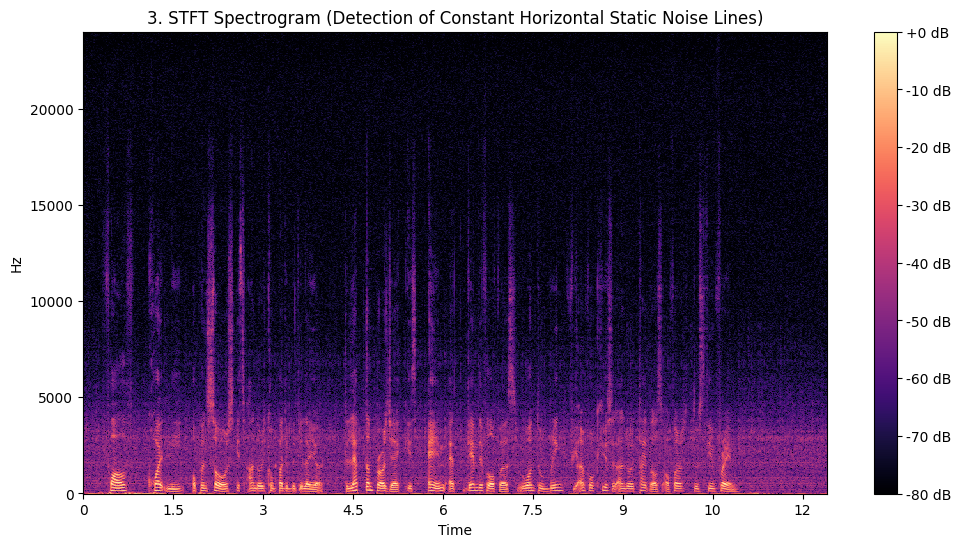

In [ ]:
# Menghitung matriks STFT dan langsung mengonversi nilai Amplitude-nya menjadi skala decibel (dB)
stft_matrix_db = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

# Menyiapkan area figur khusus untuk Spectrogram
plt.figure(figsize=(12, 6))
# Menggambar heatmap dari Spectrogram menggunakan colormap 'magma'
librosa.display.specshow(stft_matrix_db, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
# Menambahkan panel color bar vertikal di kanan sebagai legenda intensitas dB
plt.colorbar(format="%+2.0f dB")
# Memberi judul instruksional untuk mencari garis horizontal konstan
plt.title('3. STFT Spectrogram (Detection of Constant Horizontal Static Noise Lines)')
# Menampilkan heatmap Spectrogram
plt.show()

Vokal terlihat sebagai pola terang di bawah 5 kHz yang berubah tiap waktu. Latar belakangnya berupa pita noise di frekuensi rendah yang tetap ada dari awal sampai akhir, termasuk di gap antar kata. Itu ciri noise statis.

## 2.4 Mel Spectogram (Perceptual Scale)

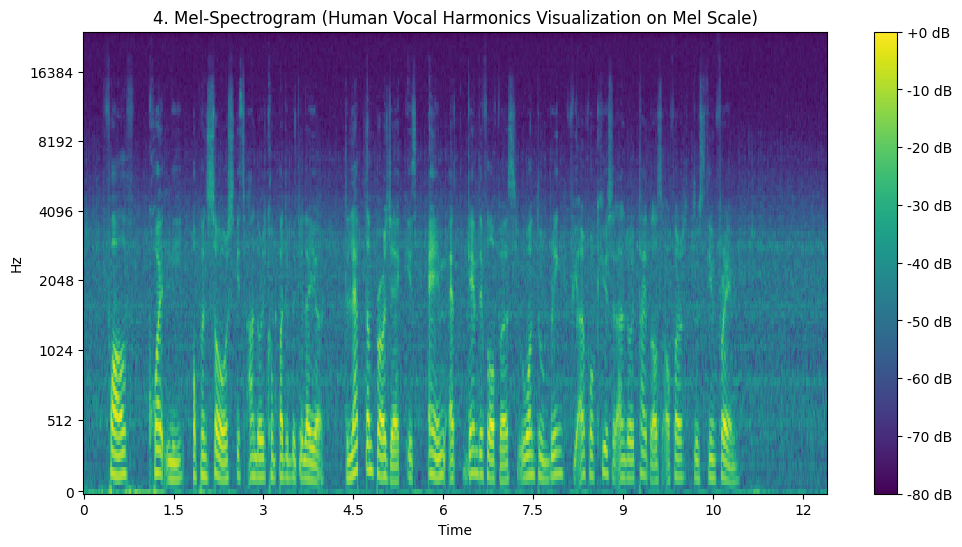

In [ ]:
# Mengekstrak daya Mel-spectrogram (128 frequency bands) dan mengonversinya ke decibel
mel_matrix_db = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128), ref=np.max)

# Menyiapkan kanvas untuk visualisasi skala Mel
plt.figure(figsize=(12, 6))
# Merender heatmap frekuensi skala Mel dengan colormap 'viridis'
librosa.display.specshow(mel_matrix_db, sr=sr, x_axis='time', y_axis='mel', cmap='viridis')
# Menambahkan color bar untuk informasi format decibel
plt.colorbar(format="%+2.0f dB")
# Menuliskan judul plot Mel-spectrogram untuk identifikasi harmonik
plt.title('4. Mel-Spectrogram (Human Vocal Harmonics Visualization on Mel Scale)')
# Menampilkan grafik keseluruhan
plt.show()

Skala Mel kira-kira linear di bawah 1 kHz dan logaritmik di atasnya, jadi area 0–1 kHz mendapat ruang lebih banyak.

# 3. Resampling & Aliasing

In [ ]:
# target freq
TARGET_SR = 8000

decimation_factor = sr // TARGET_SR

# Naive Decimation
y_naive = y[::decimation_factor]
sr_naive = sr // decimation_factor
stft_naive_db = librosa.amplitude_to_db(np.abs(librosa.stft(y_naive)), ref=np.max)

# Resampling Standar Berfilter
y_clean = librosa.resample(y, orig_sr=sr, target_sr=TARGET_SR)
stft_clean_db = librosa.amplitude_to_db(np.abs(librosa.stft(y_clean)), ref=np.max)

# Menyimpan hasil
sf.write('audio_downsampled_naive.wav', y_naive, sr_naive)
sf.write('audio_downsampled_clean.wav', y_clean, TARGET_SR)

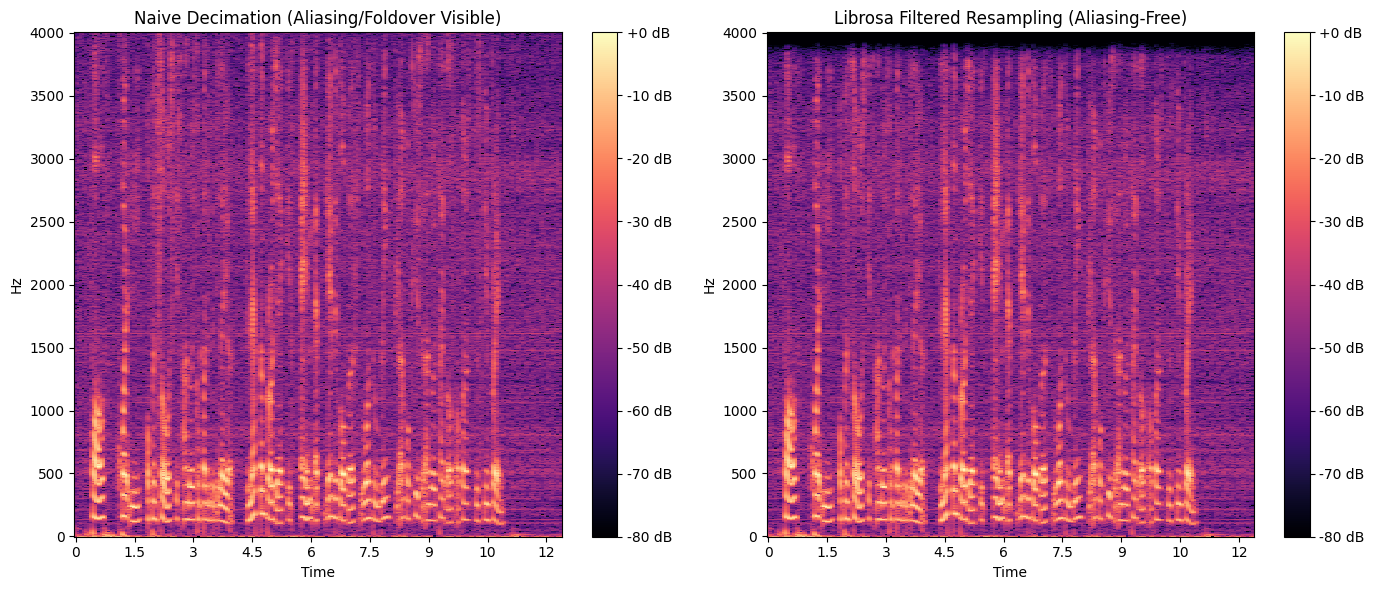

In [ ]:
plt.figure(figsize=(14, 6))

# Plot Kiri (Aliasing)
plt.subplot(1, 2, 1)
librosa.display.specshow(stft_naive_db, sr=sr_naive, x_axis='time', y_axis='hz', cmap='magma')
plt.title('Naive Decimation (Aliasing/Foldover Visible)')
plt.colorbar(format="%+2.0f dB")

# Plot Kanan (Bebas Aliasing)
plt.subplot(1, 2, 2)
librosa.display.specshow(stft_clean_db, sr=TARGET_SR, x_axis='time', y_axis='hz', cmap='magma')
plt.title('Librosa Filtered Resampling (Aliasing-Free)')
plt.colorbar(format="%+2.0f dB")

plt.tight_layout()
plt.show()

Sampling rate diturunkan dari 48 kHz ke 8 kHz. Pada naive decimation y[::6] tidak ada filter, jadi komponen di atas 4 kHz folding ke rentang 0–4 kHz. Pada resampling berfilter, komponen itu dibuang sehingga terlihat gelap di dekat 4 kHz. Perbedaannya sedikit karena rekaman asli hanya punya sedikit suara di atas 4 kHz. Selisih terukur paling jelas di band 3,6–4 kHz (±4 dB), sedangkan di bawahnya hampir sama. Artinya aliasing tetap terjadi, tapi dampaknya kecil.